<a href="https://colab.research.google.com/github/hyrinn/Deep_Learning/blob/main/2243186_%EC%A1%B0%ED%9A%A8%EB%A6%B0_5%EC%A3%BC%EC%B0%A8_%EC%8B%A4%EC%8A%B5%EC%BD%94%EB%93%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**[5주차]실습**
- 아래의 실습1), 실습2). 실습3)의 코드를 완성하시오.


###**실습1) 과잉 적합과 과소 적합(Overfitting, Underfitting)**
- **[실습목표]** 예제를 통해 실제로 과잉적합 되는 학습을 수행하고, 가중치 규제(weigt regularization), 드롭아웃(Dropout)방법을 사용하여 이를 완화해본다.



####**실습 1-1)**
- 영화 리뷰를 분류하는 IMDB 데이터세트를 통해, 리뷰 데이터를 기반으로 긍정적, 부정적 리뷰를 구분하는 모델을 작성한다.

In [1]:
print("2243186, 조효린")

2243186, 조효린


In [3]:
from google.colab import auth

auth.authenticate_user()
!gcloud config get-value account

2243186@donga.ac.kr


In [4]:
import numpy as numpy
import tensorflow as tf
import matplotlib.pyplot as plt

# 데이터 다운로드
(train_data, train_labels), (test_data, test_labels) = \
    tf.keras.datasets.imdb.load_data(num_words=1000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
# 원-핫 인코딩으로 변환하는 함수
def one_hot_sequences(sequences, dimension=1000):
    ###여기에 코드를 작성
    results = numpy.zeros((len(sequences), dimension))
    for i, word_index in enumerate(sequences):
      results[i, word_index] = 1.
    return results

In [9]:
# 학습 loss 그래프를 출력하는 함수
def print_plot(history):
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('Loss Plot')
  plt.ylabel('loss')
  plt.xlabel('epochs')
  plt.legend(['train error', 'val error'], loc='upper left')
  plt.show()

In [10]:
train_data = one_hot_sequences(train_data)
test_data = one_hot_sequences(test_data)

In [11]:
# 신경망 모델 구축
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=(1000,)))

###여기에 코드를
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])


In [12]:
# 신경망 훈련, 검증 데이터 전달
history = model.fit(train_data,
                    train_labels,
                    epochs=20,
                    batch_size=512,
                    validation_data=(test_data, test_labels),
                    verbose=2)

Epoch 1/20
49/49 - 2s - 37ms/step - accuracy: 0.7242 - loss: 0.5518 - val_accuracy: 0.8219 - val_loss: 0.4304
Epoch 2/20
49/49 - 0s - 9ms/step - accuracy: 0.8442 - loss: 0.3803 - val_accuracy: 0.8501 - val_loss: 0.3583
Epoch 3/20
49/49 - 0s - 9ms/step - accuracy: 0.8643 - loss: 0.3341 - val_accuracy: 0.8578 - val_loss: 0.3373
Epoch 4/20
49/49 - 0s - 10ms/step - accuracy: 0.8693 - loss: 0.3170 - val_accuracy: 0.8597 - val_loss: 0.3306
Epoch 5/20
49/49 - 1s - 12ms/step - accuracy: 0.8732 - loss: 0.3081 - val_accuracy: 0.8602 - val_loss: 0.3276
Epoch 6/20
49/49 - 0s - 9ms/step - accuracy: 0.8752 - loss: 0.3034 - val_accuracy: 0.8605 - val_loss: 0.3276
Epoch 7/20
49/49 - 0s - 9ms/step - accuracy: 0.8769 - loss: 0.3000 - val_accuracy: 0.8608 - val_loss: 0.3282
Epoch 8/20
49/49 - 0s - 9ms/step - accuracy: 0.8776 - loss: 0.2983 - val_accuracy: 0.8604 - val_loss: 0.3280
Epoch 9/20
49/49 - 1s - 20ms/step - accuracy: 0.8767 - loss: 0.2971 - val_accuracy: 0.8606 - val_loss: 0.3285
Epoch 10/20
49/

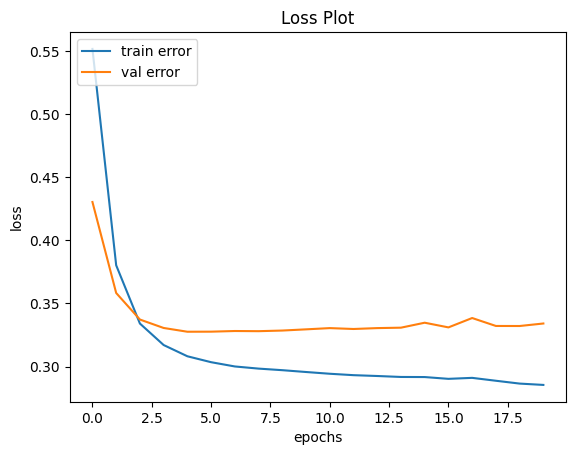

In [13]:
# 훈련 데이터의 손실값과 검증 데이터의 손실값을 그래프에 출력
print_plot(history)

####**실습1-2)**
- 실습 1-1)의 결과를 통해, 학습이 진행됨에 따라 과잉적합되는 학습의 경향을 확인할 수 있다.
- 가중치 규제 방법을 사용하여, 과잉적합을 완화해본다.

In [15]:
# 신경망 모델 구축

###여기에 코드를 작성
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(16, kernel_regularizer=tf.keras.regularizers.l2(0.001),
                              activation='relu', input_shape=(1000,)))
model.add(tf.keras.layers.Dense(16,kernel_regularizer=tf.keras.regularizers.l2(0.001),
                                activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])


# 신경망 훈련, 검증 데이터 전달
history = model.fit(train_data,
                    train_labels,
                    epochs=20,
                    batch_size=512,
                    validation_data=(test_data, test_labels),
                    verbose=2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
49/49 - 2s - 48ms/step - accuracy: 0.7330 - loss: 0.5981 - val_accuracy: 0.8272 - val_loss: 0.4562
Epoch 2/20
49/49 - 0s - 10ms/step - accuracy: 0.8500 - loss: 0.4037 - val_accuracy: 0.8551 - val_loss: 0.3848
Epoch 3/20
49/49 - 0s - 9ms/step - accuracy: 0.8646 - loss: 0.3654 - val_accuracy: 0.8612 - val_loss: 0.3711
Epoch 4/20
49/49 - 0s - 10ms/step - accuracy: 0.8718 - loss: 0.3511 - val_accuracy: 0.8612 - val_loss: 0.3678
Epoch 5/20
49/49 - 0s - 9ms/step - accuracy: 0.8736 - loss: 0.3444 - val_accuracy: 0.8594 - val_loss: 0.3682
Epoch 6/20
49/49 - 1s - 12ms/step - accuracy: 0.8741 - loss: 0.3414 - val_accuracy: 0.8604 - val_loss: 0.3643
Epoch 7/20
49/49 - 0s - 9ms/step - accuracy: 0.8737 - loss: 0.3376 - val_accuracy: 0.8598 - val_loss: 0.3641
Epoch 8/20
49/49 - 0s - 10ms/step - accuracy: 0.8752 - loss: 0.3359 - val_accuracy: 0.8604 - val_loss: 0.3609
Epoch 9/20
49/49 - 1s - 14ms/step - accuracy: 0.8759 - loss: 0.3343 - val_accuracy: 0.8578 - val_loss: 0.3649
Epoch 10/20
4

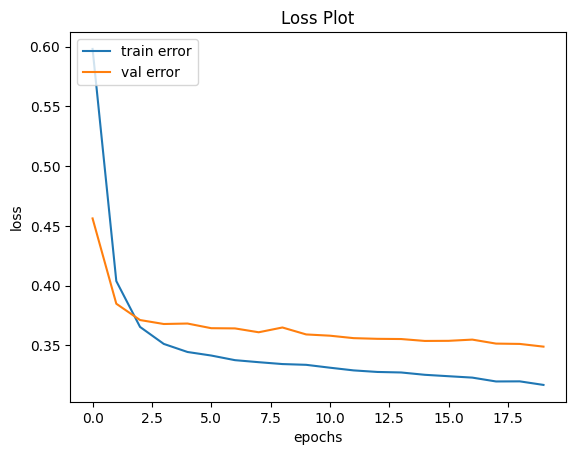

In [16]:
# 훈련 데이터의 손실값과 검증 데이터의 손실값을 그래프에 출력
print_plot(history)

####**실습1-3)**
- 드롭아웃을 수행하여, 과대적합을 완화해본다.

In [24]:
# 신경망 모델 구축

###여기에 코드를 작성


model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(16, activation='relu', input_shape=(1000,)))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])


# 신경망 훈련, 검증 데이터 전달
history = model.fit(train_data,
                    train_labels,
                    epochs=20,
                    batch_size=512,
                    validation_data=(test_data, test_labels),
                    verbose=2)

Epoch 1/20
49/49 - 2s - 46ms/step - accuracy: 0.5428 - loss: 0.6885 - val_accuracy: 0.7268 - val_loss: 0.6476
Epoch 2/20
49/49 - 1s - 11ms/step - accuracy: 0.6533 - loss: 0.6135 - val_accuracy: 0.8174 - val_loss: 0.5085
Epoch 3/20
49/49 - 1s - 11ms/step - accuracy: 0.7510 - loss: 0.5172 - val_accuracy: 0.8420 - val_loss: 0.4057
Epoch 4/20
49/49 - 0s - 10ms/step - accuracy: 0.7978 - loss: 0.4529 - val_accuracy: 0.8525 - val_loss: 0.3597
Epoch 5/20
49/49 - 1s - 16ms/step - accuracy: 0.8176 - loss: 0.4215 - val_accuracy: 0.8551 - val_loss: 0.3419
Epoch 6/20
49/49 - 1s - 12ms/step - accuracy: 0.8311 - loss: 0.3978 - val_accuracy: 0.8572 - val_loss: 0.3369
Epoch 7/20
49/49 - 1s - 16ms/step - accuracy: 0.8380 - loss: 0.3810 - val_accuracy: 0.8599 - val_loss: 0.3260
Epoch 8/20
49/49 - 1s - 25ms/step - accuracy: 0.8443 - loss: 0.3691 - val_accuracy: 0.8610 - val_loss: 0.3220
Epoch 9/20
49/49 - 1s - 21ms/step - accuracy: 0.8488 - loss: 0.3587 - val_accuracy: 0.8578 - val_loss: 0.3239
Epoch 10/2

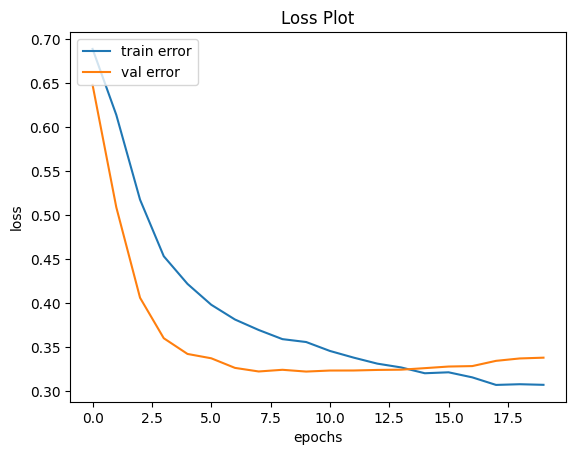

In [25]:
# 훈련 데이터의 손실값과 검증 데이터의 손실값을 그래프에 출력
print_plot(history)

###**실습2) MNIST 필기체 숫자 인식**
- **[실습목표]** tensorflow를 활용하여, MNIST dataset의 classification을 수행하는 MLP모델을 구출해본다.


In [26]:
import matplotlib.pyplot as plt
import tensorflow as tf

mnist = tf.keras.datasets.mnist

(x_train, y_train),(x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [29]:
###여기에 코드를 작성

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(512, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy'
  ,metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)
loss, acc = model.evaluate(x_test, y_test)
print(f"loss: {loss}, acc: {acc}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9362 - loss: 0.2165
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9713 - loss: 0.0957
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9783 - loss: 0.0683
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9834 - loss: 0.0529
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.9855 - loss: 0.0442
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9782 - loss: 0.0736
loss: 0.07362211495637894, acc: 0.9782000184059143


###**실습3) 패션 아이템 분류**
- **[실습목표]** fasion mnist dataset을 classification 하는 MLP 모델을 구축해본다.
- **Fashion MNIST**
  - 28x28 픽셀의 회색조(grayscale) 이미지 70,000개로 구성(traning set 60,000개, test set 10,000)
  - 10개의 클래스로 구성되며, 각 클래스는 티셔츠/탑, 바지, 스웨터, 신발 등의 패션 아이템을 나타냄.


In [31]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, layers, models

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


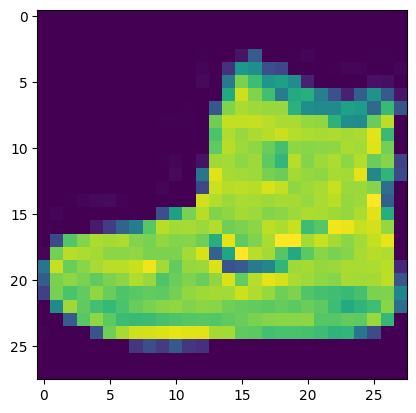

In [32]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

plt.imshow(train_images[0])

In [33]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [34]:
###여기에 코드를 작성

model = models.Sequential()
model.add(layers.Flatten(input_shape=(28, 28)))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy'
  ,metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8250 - loss: 0.4960
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8641 - loss: 0.3748
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8760 - loss: 0.3370
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8863 - loss: 0.3107
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8912 - loss: 0.2956


In [35]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('정확도:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8709 - loss: 0.3586
정확도: 0.8708999752998352
